<a href="https://colab.research.google.com/github/ArkanUbaidillah/DeepLearning_B_2411537001_ArkanUbaidillahWarman/blob/main/Praktikum3/2411537001_ArkanUbaidillahWarman_Program3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Deep Learning Minggu 3
## Recurrent Neural Network (RNN) untuk Pemrosesan Data Sekuensial

Nama: Arkan Ubaidillah Warman  
NIM: 2411537001  
Kelas: B

Praktikum ini menggunakan RNN untuk mempelajari pola pada deret sinusoidal. Setelah model awal dijalankan, ukuran hidden state juga dibandingkan untuk melihat perubahan hasil prediksi.

Bagian pertama menyiapkan library yang dipakai, membuat deret sinusoidal, lalu memecahnya menjadi potongan urutan sepanjang 10 data. Setiap potongan dipakai untuk menebak satu nilai setelahnya dan hasilnya diubah menjadi tensor PyTorch.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Membuat data urutan sinusoidal
data = np.sin(np.linspace(0, 100, 1000))
seq_length = 10

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(data, seq_length)
X = torch.FloatTensor(X).unsqueeze(-1)
y = torch.FloatTensor(y).unsqueeze(-1)

Model RNN dibuat dengan satu layer `nn.RNN` dan satu layer linear. Output pada langkah waktu terakhir dipakai sebagai dasar untuk menghasilkan satu nilai prediksi.

In [2]:
# 2. Definisi model RNN
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # ambil output terakhir
        return out

Model kemudian disiapkan untuk training. Kesalahan prediksi dihitung dengan MSELoss, sedangkan pembaruan bobot dilakukan menggunakan Adam dengan learning rate 0,01.

In [3]:
# 3. Inisialisasi model, loss, dan optimizer
model = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Training dilakukan selama 50 epoch. Pada setiap epoch, gradien dibersihkan, model membuat prediksi, loss dihitung, lalu bobot diperbarui melalui backpropagation.

In [4]:
# 4. Training loop
epochs = 50
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/50], Loss: 0.0397
Epoch [20/50], Loss: 0.0091
Epoch [30/50], Loss: 0.0012
Epoch [40/50], Loss: 0.0011
Epoch [50/50], Loss: 0.0006


Nilai loss yang tersimpan selama training digambar supaya perubahan kesalahan model dari awal sampai akhir dapat diamati dengan lebih jelas.

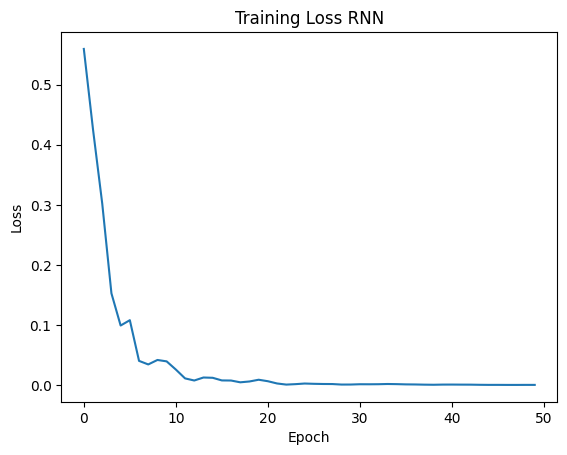

In [5]:
# 5. Plot loss
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss RNN')
plt.show()

Setelah training selesai, model dipakai untuk memprediksi seluruh urutan. Kurva hasil prediksi kemudian ditumpuk dengan data asli agar keduanya mudah dibandingkan.

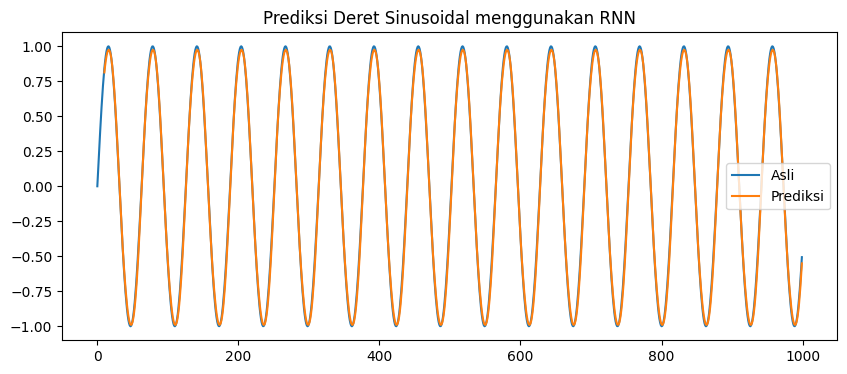

In [6]:
# 6. Prediksi
with torch.no_grad():
    preds = model(X).numpy()

plt.figure(figsize=(10,4))
plt.plot(data, label='Asli')
plt.plot(np.arange(seq_length, len(preds)+seq_length), preds, label='Prediksi')
plt.legend()
plt.title('Prediksi Deret Sinusoidal menggunakan RNN')
plt.show()

## Percobaan Hidden Size
Ukuran hidden state dibandingkan agar terlihat apakah penambahan neuron membantu model mengikuti pola sinusoidal dengan lebih baik.

Bagian ini mengulang training dengan `hidden_size` 16, 32, 64, dan 128. Seed dibuat sama pada setiap percobaan supaya perbandingan hasilnya lebih konsisten.

In [7]:
hidden_sizes = [16, 32, 64, 128]
experiment_results = []
experiment_preds = {}

for hidden_size in hidden_sizes:
    torch.manual_seed(42)
    exp_model = RNNModel(hidden_size=hidden_size)
    exp_criterion = nn.MSELoss()
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=0.01)
    exp_losses = []

    for epoch in range(50):
        exp_optimizer.zero_grad()
        exp_outputs = exp_model(X)
        exp_loss = exp_criterion(exp_outputs, y)
        exp_loss.backward()
        exp_optimizer.step()
        exp_losses.append(exp_loss.item())

    with torch.no_grad():
        exp_pred = exp_model(X).numpy()

    experiment_results.append((hidden_size, exp_losses[-1]))
    experiment_preds[hidden_size] = exp_pred
    print(f'Hidden Size {hidden_size}: Loss Akhir = {exp_losses[-1]:.6f}')

Hidden Size 16: Loss Akhir = 0.001471
Hidden Size 32: Loss Akhir = 0.000439
Hidden Size 64: Loss Akhir = 0.000136
Hidden Size 128: Loss Akhir = 0.001725


Hasil prediksi dari setiap `hidden_size` digambar pada satu grafik bersama data asli. Dari sini terlihat pengaruh jumlah neuron tersembunyi terhadap bentuk prediksi.

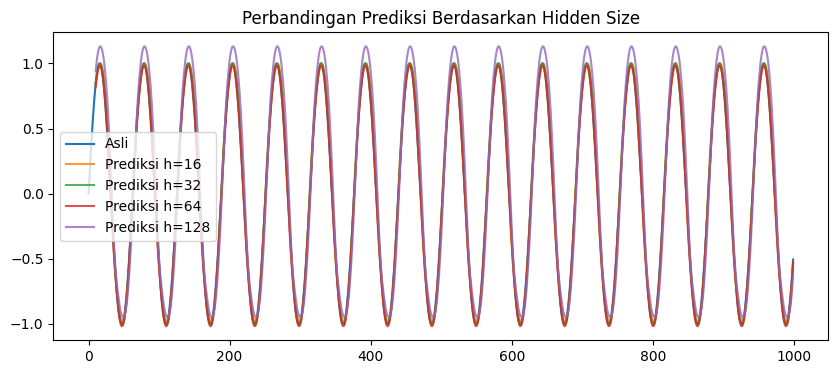

In [8]:
plt.figure(figsize=(10,4))
plt.plot(data, label='Asli')
for hidden_size in hidden_sizes:
    plt.plot(
        np.arange(seq_length, len(experiment_preds[hidden_size]) + seq_length),
        experiment_preds[hidden_size],
        label=f'Prediksi h={hidden_size}',
        alpha=0.8
    )
plt.legend()
plt.title('Perbandingan Prediksi Berdasarkan Hidden Size')
plt.show()